In [32]:
# !pip install image-reward

In [33]:
# !pip install -U ftfy botocore accelerate transformers datasets evaluate

In [34]:
# !pip install -U "timm==0.6.13" "transformers==4.27.4" "fairscale==0.4.13" "huggingface_hub==0.13.4" "accelerate==0.31.0"

In [35]:
# !pip install hpsv2x
# !pip install image-reward
# !pip install hpsv3
# !pip install clip

In [36]:
# import ImageReward as RM
# model = RM.load("ImageReward-v1.0")

In [37]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [38]:
import hpsv2

In [39]:
# !pip freeze > ir.txt

In [40]:
from hpsv3 import HPSv3RewardInferencer

# Initialize the model
inferencer = HPSv3RewardInferencer(device='cuda')

/home/wg25r/miniconda/envs/neg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Flash Attention is not installed. Falling to SDPA.


`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 5/5 [00:01<00:00,  4.12it/s]
Some weights of Qwen2VLRewardModelBT were not initialized from the model checkpoint at Qwen/Qwen2-VL-7B-Instruct and are newly initialized: ['rm_head.0.bias', 'rm_head.0.weight', 'rm_head.3.bias', 'rm_head.3.weight', 'rm_head.5.bias', 'rm_head.5.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [41]:
import json
with open("dataset.json", "r") as f:
    data = json.load(f)

In [266]:
import random
selected_commits = random.sample(list(data.keys()), 8)

In [267]:
with open("captions.json", "r") as f:
    captions = json.load(f)

In [268]:
def get_prompt(image_name):
    for i in captions:
        if i["image"] == image_name:
            return i["caption"]

In [269]:
selected_images = []
prompts = []
labels = []
for commit in selected_commits: 
    image_name = random.choice(data[commit]["images"])
    selected_images.append(image_name)
    prompts.append(get_prompt(image_name))
    labels.append(data[commit]["message"])

In [270]:
rewards = inferencer.reward(prompts[1], image_paths=[selected_images[1]])

In [271]:
rewards[0][0]

tensor(3.5840, device='cuda:0')

In [272]:
prompts[-1] = "A photograph of a classroom with students sitting at desks, a teacher standing at the front near a whiteboard, bright natural light coming through the windows"
selected_images[-1] = "download2.png"

In [273]:
import torch
scores = []
with torch.no_grad():
    for prompt, image in zip(prompts, selected_images):
        # score = hpsv2.score(image, prompt, hps_version="v2.1") 
        score = inferencer.reward(prompts=[prompt], image_paths=[image])
        scores.append(round(score[0][0].item(), 2))


In [274]:
# inferencer.reward(prompts=[prompt], image_paths=[image]) 

In [275]:
# score = inferencer.reward(image_paths=["../water-ocean-horizon-sea-preview.jpg"], prompts=["the sky decided to have a full emotional breakdown, rolling in with every shade of grey it could find, but the ocean just sat there in its gorgeous teal, unbothered, moisturized, thriving. meanwhile the sun's peeking through like 'guys can we talk about this' and the city on the horizon is just minding its own business pretending nothing's happening"])
# round(score[0][0].item(), 2)

In [276]:
with open("label_classes.json", "r") as f:
    label_classes = json.load(f)

In [277]:
new_labels = [label_classes[label].replace("_", " ").title() for label in labels] + ["SD3M"]

In [278]:
prompts

['A dim interior scene is seen through heavy analog-style blur and a dark vignette, with the shapes of chair backs and hanging plant leaves barely emerging from the shadows. Bright colored light leaks and flare-like streaks in blue, gold, pink, and green wash over the frame, creating smeared bokeh glows and a dreamy lo-fi film-defect look.',
 'A bare tree leans over a fog-choked roadside, its branches dissolving into a gray wall while the ground and distant shapes fade into near-featureless haze. The image is drained of color and tonal separation, with crushed midtones, muddy blacks, and a heavy, suffocating overcast atmosphere that makes the whole scene feel bleak and compressed.',
 'A three-panel studio-style portrait shows the same woman against a plain blue-gray backdrop, first playfully dressed with a red clown nose and blue pigtail ties, then holding a card that reads “BAD PHOTOG,” and finally posed in a pink checkered shirt. The lighting is even and soft rather than harsh, with 

In [279]:
scores

[5.02, 10.67, 13.57, -1.02, 9.08, 7.52, -1.02, 10.27]

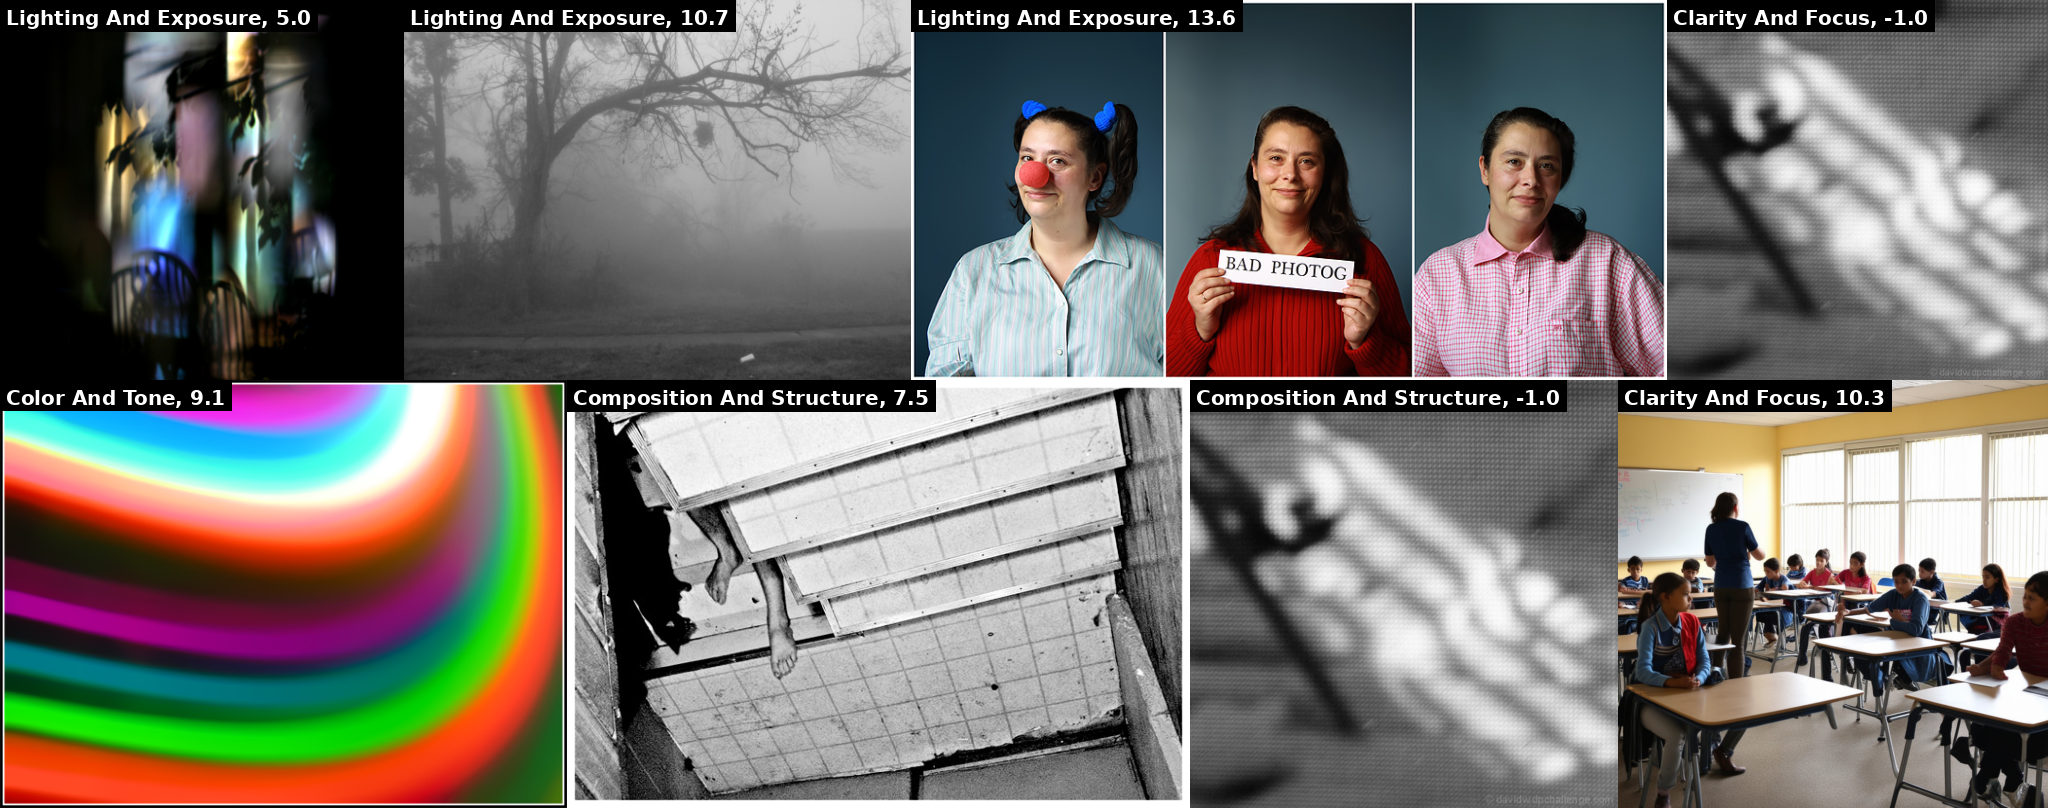

In [280]:
from image_utils import grid_stack

grid_stack(selected_images, 4, scores=[f"{new_labels[i]}, {scores[i]:0.1f}" for i in range(len(scores))], font_size=20)

In [281]:
# len(set(sum([i["images"] for i in data.values()], []))) 

In [282]:
# next(iter(data.values()))

In [283]:
# images = []
# labels = []
# for commit in data.values():
#     images.extend(commit["images"])
#     labels.extend([commit["message"]] * len(commit["images"]))
# assert len(images) == len(labels)

In [284]:
# import random
# # sampled_idx = random.sample(range(len(images)), 1000000)
# sampled_images = images#[images[i] for i in sampled_idx]
# sampled_labels = labels#[labels[i] for i in sampled_idx]

In [285]:
# from image_utils import grid_stack
# grid_stack(sampled_images[:8], 4)

In [286]:
# with open("sampled_dataset.json", "w") as f:
#     json.dump({"images": sampled_images, "labels": sampled_labels}, f)

In [287]:
5/0

ZeroDivisionError: division by zero

In [ ]:
import json
with open("captions.json", "r") as f:
    captions = json.load(f)

In [ ]:
num_of_labels = [len(i["labels"]) for i in captions]

In [ ]:
import numpy as np
np.sum(np.array(num_of_labels) > 1)

np.int64(1798)

In [ ]:
import json
with open("hpsv3.jsonl", "r") as f:
    data = [json.loads(line) for line in f]

In [ ]:
# use latest result
images_scores = {}
for item in data:
    images_scores[item["image"]] = (item["score"], item["caption"])

In [ ]:
total_mean = np.mean([item[0] for item in images_scores.values()])

In [ ]:
total_mean

np.float64(7.822168950561959)

In [ ]:
with open("captions.json", "r") as f:
    captions = json.load(f)

with open("label_classes.json", "r") as f:
    label_classes = json.load(f)

def caption_to_label(caption):
    for i in captions:
        if i["caption"] == caption:
            return [label_classes[j] for j in i["labels"]]

In [ ]:
labels_scores = {}
for i in label_classes.values():
    labels_scores[i] = []

for item in images_scores.values():
    caption = item[1]
    score = item[0]
    labels = caption_to_label(caption)
    for label in labels:
        labels_scores[label].append(score)

In [ ]:
for key in labels_scores:
    print(f"{key}: {np.mean(labels_scores[key]):.2f}")
print(f"Total: {total_mean:.2f}")

emotion_and_subject: 8.92
color_and_tone: 5.09
lighting_and_exposure: 6.78
composition_and_structure: 6.81
clarity_and_focus: 5.81
Total: 7.82


In [294]:
with open("classes_big.json") as _f:
    CLASSES_JSON = json.load(_f)

AA_CLASSES = CLASSES_JSON
VALID_BOTTOM_CLASSES = sum(list([list(i.values()) for i in list(AA_CLASSES.values())]), [])

In [296]:
len(VALID_BOTTOM_CLASSES)

15

In [293]:
[i.values() for i in list(AA_CLASSES.values())]

[dict_values(['Motion blur, shallow depth of field, soft focus, and dreamlike softening effects.', 'Double exposures, ghosted subjects, and layered overlapping frames.', 'Grain, noise, VHS decay, scanlines, datamoshing, compression errors, and lo-fi texture.']),
 dict_values(['Aggressively conflicting palettes, toxic neon, wrong object colors, and chromatic aberration.', 'Desaturated, washed-out, monotone, or retro faded tones with low vibrancy.', 'Unhealthy color casts, uneven white balance, color banding, and mixed color temperatures.']),
 dict_values(['Deliberate underexposure, overexposure, crushed shadows, or blown highlights.', 'Harsh or insufficient flash, specular hotspots, and simulated light leak streaks.', 'Absence of directional light, collapsed depth, crushed midtones, and oppressive tonal compression.']),
 dict_values(['Tilted horizons, skewed angles, off-level framing, and deliberate instability.', 'Subjects cut off, blocked, or hidden at frame edges with withheld inform